In [1]:
# Phase 1: Simulating Real-World Business Data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

%matplotlib inline
sns.set_style('whitegrid')

In [3]:
# Build the Retail Performance Matrix
np.random.seed(42)
n_products = 500

business_data = pd.DataFrame({
    'ProductID': [f'PROD_{i}' for i in range(1001, 1001 + n_products)],
    'Base_Price': np.random.uniform(20, 150, size=n_products).round(2),
    'Inventory_Age_Days': np.random.randint(10, 180, size=n_products),
    'Current_Discount_Pct': np.random.uniform(0.0, 0.60, size=n_products).round(2)
})

business_data['Units_Sold'] = (1000 / business_data['Base_Price'] * (1 + business_data['Current_Discount_Pct'] * 2.5) - (business_data['Inventory_Age_Days'] * 0.1)).astype(int)
business_data['Units_Sold'] = business_data['Units_Sold'].clip(lower=5) # Ensure no negative sales

business_data['Revenue'] = business_data['Units_Sold'] * (business_data['Base_Price'] * (1 - business_data['Current_Discount_Pct']))
business_data['Cost_Of_Goods'] = business_data['Units_Sold'] * (business_data['Base_Price'] * 0.40) # 40% base manufacturing cost
business_data['Gross_Profit'] = business_data['Revenue'] - business_data['Cost_Of_Goods']

print(f"Database Loaded. Total Revenue Tracked: ${business_data['Revenue'].sum():,.2f}")
business_data.head()

Database Loaded. Total Revenue Tracked: $352,159.96


,ProductID,Base_Price,Inventory_Age_Days,Current_Discount_Pct,Units_Sold,Revenue,Cost_Of_Goods,Gross_Profit
0,PROD_1001,68.69,154,0.46,15,556.3890,412.140,144.2490
1,PROD_1002,143.59,170,0.06,5,674.8730,287.180,387.6930
2,PROD_1003,115.16,166,0.20,5,460.6400,230.320,230.3200
3,PROD_1004,97.83,150,0.05,5,464.6925,195.660,269.0325
4,PROD_1005,40.28,55,0.45,47,1041.2380,757.264,283.9740


In [4]:
# Phase 2: Applying ML to Learn Price Elasticity


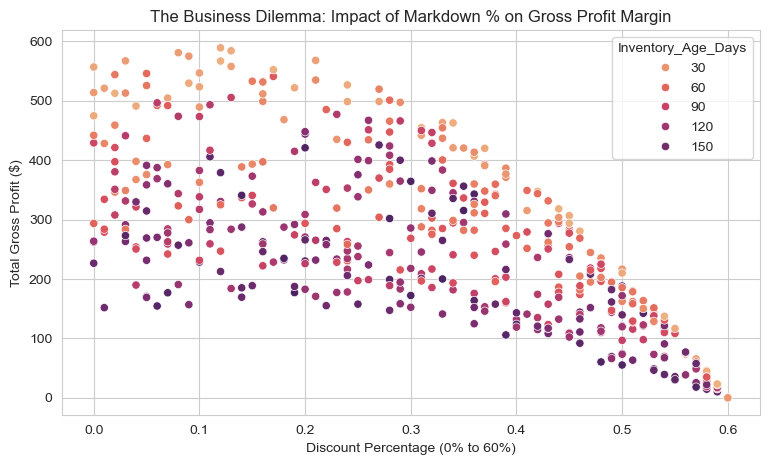

In [5]:
# Analyze the Revenue vs. Discount Dilemma
plt.figure(figsize=(9, 5))
sns.scatterplot(data=business_data, x='Current_Discount_Pct', y='Gross_Profit', hue='Inventory_Age_Days', palette='flare')
plt.title('The Business Dilemma: Impact of Markdown % on Gross Profit Margin')
plt.xlabel('Discount Percentage (0% to 60%)')
plt.ylabel('Total Gross Profit ($)')
plt.show()

In [7]:
# Train the Demand Elasticity Model
X_features = business_data[['Current_Discount_Pct', 'Inventory_Age_Days']]
X_features = sm.add_constant(X_features) # Add baseline intercept
y_target = business_data['Units_Sold']

ml_model = sm.OLS(y_target, X_features).fit()
print(ml_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Units_Sold   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     31.07
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           1.93e-13
Time:                        22:04:42   Log-Likelihood:                -2153.4
No. Observations:                 500   AIC:                             4313.
Df Residuals:                     497   BIC:                             4325.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   14.6076 

In [8]:
# Phase 3: The Optimization Logic (Maximizing Profit)


In [9]:
# Run the Markdown Optimizer


In [10]:
optimized_discounts = []
predicted_profits = []

for idx, row in business_data.iterrows():
    best_discount = 0.0
    max_profit = -999999
    
    for test_discount in np.arange(0.0, 0.55, 0.05):
        # Predict sales volume using our trained ML coefficients
        pred_units = ml_model.params['const'] + (ml_model.params['Current_Discount_Pct'] * test_discount) + (ml_model.params['Inventory_Age_Days'] * row['Inventory_Age_Days'])
        pred_units = max(5, int(pred_units))
        
        test_revenue = pred_units * (row['Base_Price'] * (1 - test_discount))
        test_cost = pred_units * (row['Base_Price'] * 0.40)
        test_profit = test_revenue - test_cost
        
        if test_profit > max_profit:
            max_profit = test_profit
            best_discount = test_discount
            
    optimized_discounts.append(best_discount)
    predicted_profits.append(max_profit)

business_data['Recommended_Discount'] = optimized_discounts
business_data['Optimized_Predicted_Profit'] = predicted_profits
print("AI Markdown Optimization Complete!")

AI Markdown Optimization Complete!


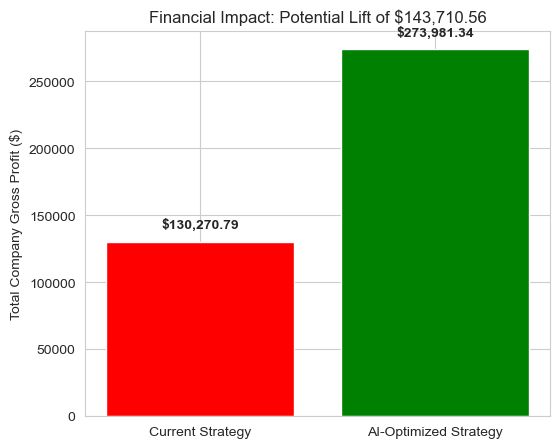

In [11]:
# Visualizing the Financial Lift for Executives
current_total_profit = business_data['Gross_Profit'].sum()
optimized_total_profit = business_data['Optimized_Predicted_Profit'].sum()
financial_lift = optimized_total_profit - current_total_profit

plt.figure(figsize=(6, 5))
bars = plt.bar(['Current Strategy', 'AI-Optimized Strategy'], [current_total_profit, optimized_total_profit], color=['red', 'green'])
plt.title(f'Financial Impact: Potential Lift of ${financial_lift:,.2f}')
plt.ylabel('Total Company Gross Profit ($)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 10000, f"${yval:,.2f}", ha='center', fontweight='bold')

plt.show()